# `toolbox_ml` — Notebook de demostración

Demostración de todas las funciones del paquete `toolbox_ml` sobre un dataset real.

**Dataset:** Titanic (891 pasajeros, 15 columnas). Tiene justo la mezcla necesaria para
probar el paquete entero: variables numéricas continuas y discretas, variables
categóricas de 2 y de más de 2 niveles, y columnas con nulos.

**Target elegido:** `fare` (la tarifa pagada, en libras). Es una variable **numérica
continua**, que es lo que exigen las funciones `*_regression` del paquete. Descarto
`survived` porque es binaria y estas funciones están pensadas para regresión.

**Instalación previa:**

```bash
pip install -r requirements.txt
pip install -e .
```

## 0. Imports

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from toolbox_ml.eda.core import (
    describe_df,
    tipifica_variables,
    get_features_num_regression,
    plot_features_num_regression,
    get_features_cat_regression,
    plot_features_cat_regression,
    detect_outliers,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = sns.load_dataset("titanic")
print(f"Titanic: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Titanic: 891 filas x 15 columnas


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. `describe_df` — radiografía del DataFrame

Primera parada en cualquier EDA: ¿qué tipos hay, cuántos nulos y qué cardinalidad tiene
cada columna? En una sola tabla.

In [2]:
resumen = describe_df(df)
resumen

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
survived,int64,0.00,2,0.22
pclass,int64,0.00,3,0.34
sex,str,0.00,2,0.22
age,float64,19.87,88,9.88
sibsp,int64,0.00,7,0.79
parch,int64,0.00,7,0.79
fare,float64,0.00,248,27.83
embarked,str,0.22,3,0.34
class,category,0.00,3,0.34
who,str,0.00,3,0.34


**Lectura:** `deck` tiene un **77% de nulos** (candidata a descarte), `age` un 19,87%
(habrá que imputar). `who`, `sex`, `alive` y `adult_male` tienen cardinalidades muy bajas:
son categóricas. Y ninguna columna llega al 100% de cardinalidad, así que no hay
identificadores únicos que descartar.

## 2. `tipifica_variables` — ¿qué es cada columna?

Sugiere el tipo de cada variable según su cardinalidad. Los dos umbrales son decisión mía:
con `umbral_categoria=10` fijo que menos de 10 valores distintos es categórica, y con
`umbral_continua=15.0`, que si los valores únicos superan el 15% de las filas la trato
como continua.

In [3]:
tipos = tipifica_variables(df, umbral_categoria=10, umbral_continua=15.0)
tipos

,nombre_variable,tipo_sugerido
0,survived,Binaria
1,pclass,Categórica
2,sex,Binaria
3,age,Numérica Discreta
4,sibsp,Categórica
5,parch,Categórica
6,fare,Numérica Continua
7,embarked,Categórica
8,class,Categórica
9,who,Categórica


**Lectura:** `fare` sale como *Numérica Continua* (248 valores distintos, un 27,8% de
cardinalidad) y `sibsp`, `parch` y `deck` como *Categórica* (7 valores cada una). Ojo con
`age`: la función la clasifica como *Numérica Discreta* porque sus 88 valores únicos son
solo el 9,88% de las filas, por debajo del umbral del 15% que le hemos puesto. No es un
error de la función, es lo que le he pedido: **para que `age` saliera continua habría que
bajar `umbral_continua` por debajo de 9,88**. Los umbrales son una decisión del
analista, no una verdad del dataset.

## 3. `get_features_num_regression` — variables numéricas que explican el target

Devuelve las columnas numéricas cuya correlación de Pearson con `fare` supera el umbral,
ordenadas de mayor a menor correlación absoluta.

In [4]:
# sin filtro estadistico: solo el umbral de correlacion
print("Umbral 0.2, sin filtro de p-valor:")
print(" ", get_features_num_regression(df, target_col="fare", umbral_corr=0.2))

# ahora exijo ademas significacion estadistica
print("\nUmbral 0.2 + p-valor < 0.05:")
print(" ", get_features_num_regression(df, target_col="fare", umbral_corr=0.2, pvalue=0.05))

# subiendo el umbral solo sobreviven las mas fuertes
print("\nUmbral 0.5:")
print(" ", get_features_num_regression(df, target_col="fare", umbral_corr=0.5))

Umbral 0.2, sin filtro de p-valor:
  ['pclass', 'survived', 'parch']

Umbral 0.2 + p-valor < 0.05:
  ['pclass', 'survived', 'parch']

Umbral 0.5:
  ['pclass']


**Lectura:** `pclass` es la variable más correlacionada con la tarifa, y con signo
negativo (clase 1 = tarifas altas, clase 3 = tarifas bajas). Le siguen `survived` y
`parch`. Al subir el umbral a 0.5 **solo sobrevive `pclass`**: es la única variable
numérica que explica la tarifa con esa fuerza por sí sola.

## 4. `plot_features_num_regression` — las mismas, pero dibujadas

Misma lógica de selección, pero pintando un pairplot. Si hay más de 5 columnas las
reparte en varios pairplots para que se sigan leyendo.

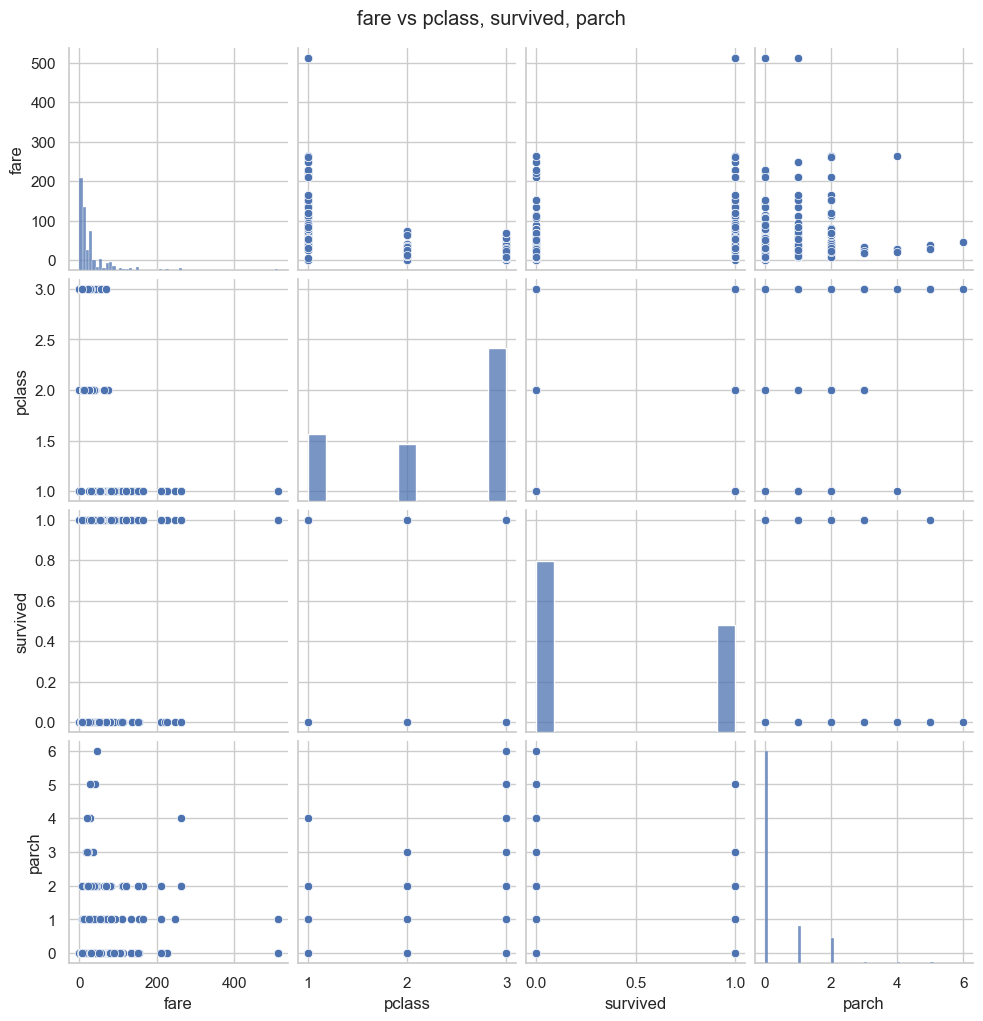

Columnas representadas: ['pclass', 'survived', 'parch']


In [5]:
pintadas = plot_features_num_regression(df, target_col="fare", umbral_corr=0.2, pvalue=0.05)
print("Columnas representadas:", pintadas)

## 5. `get_features_cat_regression` — variables categóricas que explican el target

Aquí no vale Pearson: el paquete elige el test automáticamente según la cardinalidad.
Con 2 categorías aplica **Mann-Whitney U**; con más de 2, **ANOVA de un factor**.

In [6]:
significativas = get_features_cat_regression(df, target_col="fare", pvalue=0.05)
print("Categoricas relacionadas con 'fare' (p < 0.05):")
for c in significativas:
    print(f"   - {c:<14} ({df[c].nunique()} categorias -> "
          f"{'Mann-Whitney U' if df[c].nunique() == 2 else 'ANOVA'})")

# con un nivel de exigencia mucho mayor sobreviven menos
print("\nCon p < 0.001:", get_features_cat_regression(df, target_col="fare", pvalue=0.001))

Categoricas relacionadas con 'fare' (p < 0.05):
   - sex            (2 categorias -> Mann-Whitney U)
   - embarked       (3 categorias -> ANOVA)
   - class          (3 categorias -> ANOVA)
   - who            (3 categorias -> ANOVA)
   - adult_male     (2 categorias -> Mann-Whitney U)
   - deck           (7 categorias -> ANOVA)
   - embark_town    (3 categorias -> ANOVA)
   - alive          (2 categorias -> Mann-Whitney U)
   - alone          (2 categorias -> Mann-Whitney U)

Con p < 0.001: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


**Lectura:** salen significativas **las nueve** categóricas del dataset, y con p < 0.001
todas siguen pasando. No es un fallo del test: con 891 filas, diferencias pequeñas ya
resultan estadísticamente significativas. Es el recordatorio clásico de que
**significación no es lo mismo que relevancia** — habría que mirar además el tamaño del
efecto. Las que tienen sentido de negocio son `class` y `deck`: la tarifa depende de la
clase y de la cubierta del camarote.

## 6. `plot_features_cat_regression` — histogramas por categoría

Pinta la distribución de `fare` separada por cada valor de la categórica. Con
`with_individual_plot=False` van todas en una figura; con `True`, una figura por variable.

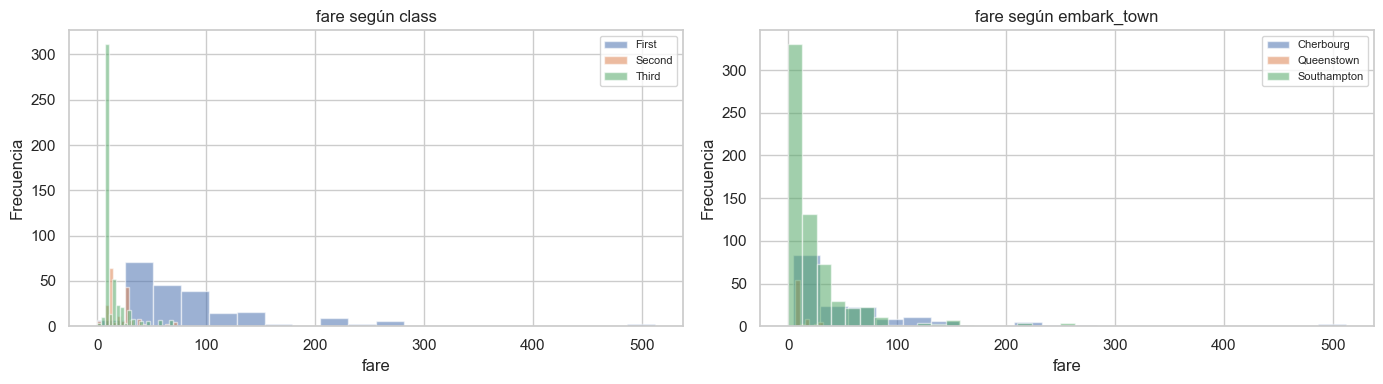

Columnas representadas: ['class', 'embark_town']


In [7]:
pintadas_cat = plot_features_cat_regression(
    df,
    target_col="fare",
    columns=["class", "embark_town"],
    pvalue=0.05,
    with_individual_plot=False,
)
print("Columnas representadas:", pintadas_cat)

## 7. `detect_outliers` (bonus) — atípicos por IQR y por Z-score

Devuelve, para cada columna numérica, cuántos outliers hay, qué porcentaje representan
y en qué índices están.

In [8]:
por_iqr = detect_outliers(df, columns=["age", "fare"], metodo="iqr", umbral=1.5)
por_z = detect_outliers(df, columns=["age", "fare"], metodo="zscore", umbral=3)

comparativa = pd.DataFrame({
    "IQR (n)": {c: v["n_outliers"] for c, v in por_iqr.items()},
    "IQR (%)": {c: v["porcentaje"] for c, v in por_iqr.items()},
    "Z-score (n)": {c: v["n_outliers"] for c, v in por_z.items()},
    "Z-score (%)": {c: v["porcentaje"] for c, v in por_z.items()},
})
display(comparativa)

print("Primeros indices con tarifa atipica (IQR):", por_iqr["fare"]["indices"][:10])
print("Tarifa maxima del dataset:", df["fare"].max())

,IQR (n),IQR (%),Z-score (n),Z-score (%)
age,11,1.23,2,0.22
fare,116,13.02,20,2.24


Primeros indices con tarifa atipica (IQR): [1, 27, 31, 34, 52, 61, 62, 72, 88, 102]
Tarifa maxima del dataset: 512.3292


**Lectura:** los dos métodos no coinciden, y eso es lo esperable: el IQR es más estricto
y marca bastantes más tarifas altas, mientras que el Z-score solo señala los extremos
puros. `fare` tiene una cola derecha muy larga (hay billetes de 512 libras), así que
aquí el IQR está haciendo bien su trabajo.

## 8. Comprobaciones de entrada

Todas las funciones validan sus argumentos: si algo está mal, **imprimen el motivo y
devuelven `None`** en lugar de lanzar una excepción. Así un error no rompe el notebook.

In [9]:
print("1) El input no es un DataFrame:")
print("   ->", describe_df("esto no es un dataframe"))

print("\n2) La columna target no existe:")
print("   ->", get_features_num_regression(df, target_col="no_existe", umbral_corr=0.5))

print("\n3) El target no es numerico ('sex' es categorica):")
print("   ->", get_features_num_regression(df, target_col="sex", umbral_corr=0.5))

print("\n4) El umbral de correlacion esta fuera de [0, 1]:")
print("   ->", get_features_num_regression(df, target_col="fare", umbral_corr=5))

print("\n5) umbral_categoria negativo:")
print("   ->", tipifica_variables(df, umbral_categoria=-3, umbral_continua=50.0))

print("\n6) Metodo de outliers inexistente:")
print("   ->", detect_outliers(df, metodo="inventado"))

1) El input no es un DataFrame:
Error: se esperaba un pd.DataFrame y se recibió str.
   -> None

2) La columna target no existe:
Error: la columna 'no_existe' no existe en el DataFrame.
   -> None

3) El target no es numerico ('sex' es categorica):
Error: la columna 'sex' debe ser numérica para un problema de regresión.
   -> None

4) El umbral de correlacion esta fuera de [0, 1]:
Error: 'umbral_corr' debe estar entre 0 y 1, y vale 5.
   -> None

5) umbral_categoria negativo:
Error: 'umbral_categoria' debe ser positivo, y vale -3.
   -> None

6) Metodo de outliers inexistente:
Error: 'metodo' debe ser 'iqr' o 'zscore', y se recibió 'inventado'.
   -> None


## 9. Flujo completo: del DataFrame crudo a las features del modelo

Encadenando las funciones se obtiene en pocas líneas la lista de variables candidatas
para un modelo de regresión sobre `fare`.

In [10]:
UMBRAL_CORR = 0.2
P_VALOR = 0.05

num = get_features_num_regression(df, "fare", umbral_corr=UMBRAL_CORR, pvalue=P_VALOR)
cat = get_features_cat_regression(df, "fare", pvalue=P_VALOR)

# descarto lo que el EDA desaconseja: mas de un 50% de nulos
calidad = describe_df(df)
demasiados_nulos = calidad[calidad["porcentaje_nulos"] > 50].index.tolist()

features = [c for c in num + cat if c not in demasiados_nulos]

print(f"Numericas seleccionadas : {num}")
print(f"Categoricas seleccionadas: {cat}")
print(f"Descartadas por nulos (>50%): {demasiados_nulos}")
print(f"\nFEATURES FINALES para modelar 'fare': {features}")

Numericas seleccionadas : ['pclass', 'survived', 'parch']
Categoricas seleccionadas: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Descartadas por nulos (>50%): ['deck']

FEATURES FINALES para modelar 'fare': ['pclass', 'survived', 'parch', 'sex', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


---

## Conclusión

El paquete cubre el recorrido completo de un EDA orientado a regresión:

| Paso | Función |
|---|---|
| Radiografía del dataset | `describe_df` |
| Clasificar las variables | `tipifica_variables` |
| Seleccionar numéricas | `get_features_num_regression` |
| Visualizar numéricas | `plot_features_num_regression` |
| Seleccionar categóricas | `get_features_cat_regression` |
| Visualizar categóricas | `plot_features_cat_regression` |
| Detectar atípicos | `detect_outliers` (bonus) |

**Para ejecutar los tests:**

```bash
pytest tests/ -v
```